In [1]:
## Load packages 
import tensorflow as tf
import numpy as np
import pandas as pd
import pyfaidx
from collections import Counter, defaultdict, OrderedDict
import logomaker
from copy import deepcopy
from tqdm import tqdm
from tqdm import tnrange
import pyBigWig
import tqdm
import sys
import pyfaidx
sys.path.append("../../../chrombpnet/")
from training.utils.losses import multinomial_nll
from training.utils.one_hot import dna_to_one_hot
from evaluation.interpret.shap_utils import *
import shap
import glob
tf.compat.v1.disable_eager_execution()
from scipy.spatial.distance import jensenshannon
from numpy.linalg import norm
from scipy.stats import wasserstein_distance
import scipy.stats
import pandas as pd
import seaborn as sns
import matplotlib
import hdf5plugin
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import h5py
import pyBigWig
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import get_custom_objects
import sys
sys.path.append("../../../src/")
custom_objects={"tf":tf, "multinomial_nll":multinomial_nll}    
get_custom_objects().update(custom_objects)
from tensorflow import keras
import deepdish as dd
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from numba import njit
from numba import prange

RuntimeError: module compiled against API version 0x10 but this version of numpy is 0xf

In [40]:
### This is for making panels for Figure 5 to show motif enrichment in low-SHAP correlated peaks
### Here we need three files, schisto, Smed, and the files with SHAP correlation to pull out the right file 
schisto_pm = pd.read_csv("../../motif_filtration/schisto/schisto_schistopeaks_neural_mean_motifs_SHAP_filtered_98_2_22_26.tsv",sep="\t")
Smed_pm = pd.read_csv('../../motif_filtration/schisto/Smed_schistopeaks_neural_mean_motifs_SHAP_filtered_98_2_22_26.tsv',sep="\t")
schisto_pm['Peak'] = schisto_pm['peak_chrom'] + ":" + (schisto_pm['peak_start']+1).astype(str) + "-" + schisto_pm['peak_end'].astype(str)
Smed_pm['Peak'] = Smed_pm['peak_chrom'] + ":" + (Smed_pm['peak_start']+1).astype(str) + "-" + Smed_pm['peak_end'].astype(str)

In [41]:
peaks = pd.read_csv("./across_species/schisto_peaks_profile_SHAP/neural_peaks_withallinfo_filtered.csv", sep="\t")
peaks = peaks[peaks.corr_neural >0.55]
peaks = peaks[peaks.corr_neural_SHAP < 0.5]


In [42]:
schisto_pm_0_5 = schisto_pm[schisto_pm.Peak.isin(peaks.Peak)]

In [43]:
Smed_pm_0_5 = Smed_pm[Smed_pm.Peak.isin(peaks.Peak)]

In [44]:
schisto_pm_mt = pd.crosstab(schisto_pm_0_5['Peak'], schisto_pm_0_5['key'])

In [45]:
Smed_pm_mt = pd.crosstab(Smed_pm_0_5['Peak'], Smed_pm_0_5['key'])

In [46]:
all_peaks = sorted(set(schisto_pm_mt.index) | set(Smed_pm_mt.index))
all_motifs = sorted(set(schisto_pm_mt.columns) | set(Smed_pm_mt.columns))

In [47]:
schisto_pm_mt = schisto_pm_mt.reindex(index=all_peaks, columns=all_motifs, fill_value=0)
Smed_pm_mt = Smed_pm_mt.reindex(index=all_peaks, columns=all_motifs, fill_value=0)

In [48]:
schisto_pm_mt

key,JC_0000,JC_0001,JC_0002,JC_0003,JC_0004,JC_0005,JC_0006,JC_0008,JC_0009,JC_0010,...,WC_2041,WC_2042,WC_2043,WC_2044,WC_2046,WC_2047,WC_2048,WC_2049,WC_2050,WC_2051
Peak,,,,,,,,,,,,,,,,,,,,,
SM_V7_1:11495085-11495653,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SM_V7_1:11540577-11540836,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SM_V7_1:12197550-12198188,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SM_V7_1:12641047-12641277,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
SM_V7_1:12663653-12664671,2,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SM_V7_ZW:9784664-9785537,0,0,0,0,0,0,13,0,1,0,...,0,0,0,0,0,0,0,0,0,0
SM_V7_ZWH018:23209-23700,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SM_V7_ZWU004:13146-13730,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
Smed_pm_mt

key,JC_0000,JC_0001,JC_0002,JC_0003,JC_0004,JC_0005,JC_0006,JC_0008,JC_0009,JC_0010,...,WC_2041,WC_2042,WC_2043,WC_2044,WC_2046,WC_2047,WC_2048,WC_2049,WC_2050,WC_2051
Peak,,,,,,,,,,,,,,,,,,,,,
SM_V7_1:11495085-11495653,0,0,0,0,0,0,2,0,0,0,...,0,0,1,0,0,0,0,0,0,0
SM_V7_1:11540577-11540836,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SM_V7_1:12197550-12198188,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SM_V7_1:12641047-12641277,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SM_V7_1:12663653-12664671,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SM_V7_ZW:9784664-9785537,0,0,0,0,0,0,5,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SM_V7_ZWH018:23209-23700,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SM_V7_ZWU004:13146-13730,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
from numba import prange

def bsFeatureEnrichmentSamePeaks(obsA, obsB, nBS=1000):
    """
    Compare motif enrichment between two conditions (Ctrl vs LTP)
    for the same set of peaks using bootstrap randomization.

    obsA, obsB : arrays (nPeaks × nMotifs)
        Binary or count matrices of motif presence per peak.
        Must have identical shape (same peaks, same motifs).

    Returns:
        fA, fB  : true fractions of peaks containing motif (0–1)
        enrObs  : log2 enrichment (B over A), computed with pseudocounts
        mu      : mean bootstrap enrichment
        p       : empirical p-values
    """
    nPeaks, nMotifs = obsA.shape

    # --- True binary fractions for plotting (no pseudocounts)
    fA = np.sum(obsA > 0, axis=0) / nPeaks
    fB = np.sum(obsB > 0, axis=0) / nPeaks

    # --- Pseudocount-stabilized frequencies for enrichment
    fA_safe = (np.sum(obsA, axis=0) + 1) / (nPeaks + 1)
    fB_safe = (np.sum(obsB, axis=0) + 1) / (nPeaks + 1)
    enrObs = np.log2(fB_safe) - np.log2(fA_safe)

    # --- Bootstrap resampling
    enrBs = np.zeros((nBS, nMotifs))
    np.random.seed(42)
    for i in prange(nBS):
        flipMask = np.random.rand(nPeaks) < 0.5
        bsA = np.where(flipMask[:, None], obsB, obsA)
        bsB = np.where(flipMask[:, None], obsA, obsB)
        fA_bs = (np.sum(bsA, axis=0) + 1) / (nPeaks + 1)
        fB_bs = (np.sum(bsB, axis=0) + 1) / (nPeaks + 1)
        enrBs[i, :] = np.log2(fB_bs) - np.log2(fA_bs)

    # --- Mean bootstrap enrichment
    mu = np.zeros(nMotifs)
    for j in range(nMotifs):
        mu[j] = np.sum(enrBs[:, j]) / nBS

    # --- Empirical p-values
    p = np.zeros(nMotifs)
    for j in range(nMotifs):
        count = 0
        for i in range(nBS):
            if np.abs(enrBs[i, j] - mu[j]) >= np.abs(enrObs[j]):
                count += 1
        p[j] = count / nBS

    return fA, fB, enrObs, mu, p

In [50]:
import numpy as np

def bsFeatureEnrichmentSamePeaks(obsA, obsB, nBS=1000, seed=42):
    """
    Compare motif enrichment between two conditions for the same set of peaks
    using bootstrap randomization (swap labels per-peak with p=0.5).

    Returns:
        fA, fB  : true fractions of peaks containing motif (0–1)
        enrObs  : log2 enrichment (B over A), computed with pseudocounts
        mu      : mean bootstrap enrichment
        p       : empirical p-values (add-one corrected; never 0)
    """
    obsA = np.asarray(obsA)
    obsB = np.asarray(obsB)
    if obsA.shape != obsB.shape:
        raise ValueError(f"obsA and obsB must have identical shape; got {obsA.shape} vs {obsB.shape}")

    nPeaks, nMotifs = obsA.shape

    # --- True binary fractions for plotting (no pseudocounts)
    fA = (obsA > 0).sum(axis=0) / nPeaks
    fB = (obsB > 0).sum(axis=0) / nPeaks

    # --- Pseudocount-stabilized frequencies for enrichment
    fA_safe = (obsA.sum(axis=0) + 1) / (nPeaks + 1)
    fB_safe = (obsB.sum(axis=0) + 1) / (nPeaks + 1)
    enrObs = np.log2(fB_safe) - np.log2(fA_safe)

    # --- Bootstrap resampling (vectorized over motifs; loop over nBS only)
    rng = np.random.default_rng(seed)
    enrBs = np.empty((nBS, nMotifs), dtype=float)

    for i in range(nBS):
        flip = rng.random(nPeaks) < 0.5  # True -> swap labels for that peak
        bsA = np.where(flip[:, None], obsB, obsA)
        bsB = np.where(flip[:, None], obsA, obsB)

        fA_bs = (bsA.sum(axis=0) + 1) / (nPeaks + 1)
        fB_bs = (bsB.sum(axis=0) + 1) / (nPeaks + 1)
        enrBs[i, :] = np.log2(fB_bs) - np.log2(fA_bs)

    # --- Mean bootstrap enrichment
    mu = enrBs.mean(axis=0)

    # --- Empirical p-values (two-sided, centered at mu), add-one corrected (never 0)
    abs_obs = np.abs(enrObs)                          # since abs(mu-centered) == abs(enrObs - 0) after centering below
    abs_bs = np.abs(enrBs - mu[None, :])

    # counts per motif: how many bootstrap deviations are >= observed deviation
    counts = (abs_bs >= abs_obs[None, :]).sum(axis=0)

    # ✅ add-one correction prevents zeros
    p = (counts + 1) / (nBS + 1)

    return fA, fB, enrObs, mu, p

In [51]:
schisto_obs = schisto_pm_mt.to_numpy()
Smed_obs  = Smed_pm_mt.to_numpy()
motif_names = schisto_pm_mt.columns.to_numpy()
fA, fB, enrObs, mu, p = bsFeatureEnrichmentSamePeaks(schisto_obs, Smed_obs, nBS=10000)


In [52]:
df_enr = pd.DataFrame({
    'motif': motif_names,
    'Fraction_schisto': fA,
    'Fraction_Smed': fB,
    'log2FC_Smed_over_schisto': enrObs,
    'p_value': p,
    '-log10_p': -np.log10(p + 1e-6),
})

# Sort by enrichment and significance (optional)
df_enr_sorted = df_enr.sort_values(['log2FC_Smed_over_schisto', '-log10_p'], ascending=[False, False])

In [53]:
df_enr_sorted

,motif,Fraction_schisto,Fraction_Smed,log2FC_Smed_over_schisto,p_value,-log10_p
1037,WC_1555,0.000000,0.021756,4.954196,0.000100,3.995722
153,JC_0170,0.000000,0.008547,4.523562,0.000400,3.396899
50,JC_0051,0.000000,0.008547,3.584963,0.001000,2.999609
879,WC_1219,0.000000,0.005439,3.584963,0.009599,2.017727
225,JC_0250,0.000000,0.004662,3.321928,0.016898,1.772131
...,...,...,...,...,...,...
828,WC_1062,0.013986,0.000000,-4.247928,0.000100,3.995722
830,WC_1065,0.013986,0.000000,-4.247928,0.000100,3.995722
97,JC_0104,0.012432,0.000000,-4.459432,0.000200,3.696847
208,JC_0231,0.016317,0.000000,-4.906891,0.000100,3.995722


In [54]:
Smed_motifs = df_enr_sorted[(df_enr_sorted.log2FC_Smed_over_schisto > 1) & (df_enr_sorted.p_value < 0.05)]

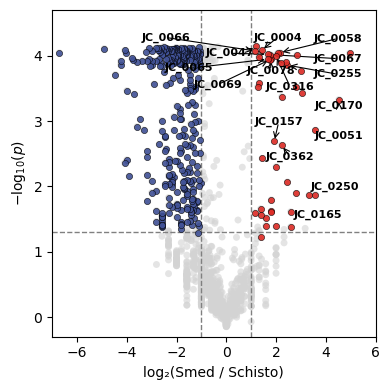

In [57]:
import numpy as np
from adjustText import adjust_text
import matplotlib.pyplot as plt

# --- data ---
x = df_enr_sorted["log2FC_Smed_over_schisto"]
neglogp = df_enr_sorted["-log10_p"]
motif_names = df_enr_sorted["motif"]

# jitter for display only (same length/order as df_enr_sorted)
rng = np.random.default_rng(0)
y_plot = neglogp + rng.uniform(-0.15, 0.15, size=neglogp.shape)

# --- thresholds ---
log2fc_thr = 1.0
p_thr = 0.05
neglogp_thr = -np.log10(p_thr)

# --- masks ---
sig = neglogp >= neglogp_thr
right_sig = sig & (x >= log2fc_thr)
left_sig  = sig & (x <= -log2fc_thr)

plt.figure(figsize=(4, 4))

# background
plt.scatter(
    x, y_plot,
    s=25, alpha=0.6,
    color="lightgrey",
    edgecolors="none",
    rasterized=True
)

# right significant
plt.scatter(
    x[right_sig], y_plot[right_sig],
    s=20, alpha=0.9,
    color="#de2c26",
    edgecolors="black",
    linewidths=0.4,
    zorder=5,
    rasterized=True
)

# left significant
plt.scatter(
    x[left_sig], y_plot[left_sig],
    s=20, alpha=0.9,
    color="#415297",
    edgecolors="black",
    linewidths=0.4,
    zorder=5,
    rasterized=True
)

# guide lines
plt.axhline(neglogp_thr, color="grey", linestyle="--", lw=1)
plt.axvline(log2fc_thr,  color="grey", linestyle="--", lw=1)
plt.axvline(-log2fc_thr, color="grey", linestyle="--", lw=1)

# ---- KEY FIX: use the jittered y values for the labels ----
# Make a quick lookup table of motif -> (x, y_jittered)
tmp = df_enr_sorted[["motif", "log2FC_Smed_over_schisto"]].copy()
tmp["y_jitter"] = y_plot.values
tmp = tmp.drop_duplicates("motif")  # just in case motif appears >1 time

motifs_to_label = ['JC_0004','JC_0047','JC_0051','JC_0058','JC_0065',
                   'JC_0066','JC_0067','JC_0069','JC_0078','JC_0157',
                   'JC_0165','JC_0170','JC_0250','JC_0255','JC_0316','JC_0362']

texts = []
for m in motifs_to_label:
    row = tmp.loc[tmp["motif"] == m]
    if not row.empty:
        row = row.iloc[0]
        texts.append(
            plt.text(
                row["log2FC_Smed_over_schisto"],
                row["y_jitter"],          # ⭐ use jittered y so it sits on the dot
                m,
                fontsize=8,
                weight="bold",
                color="black",
                zorder=10
            )
        )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color="black", lw=0.8),
    expand_points=(1.2, 1.2),
    expand_text=(1.1, 1.3),
    force_text=0.7,
    force_points=0.5
)

plt.xlabel("log₂(Smed / Schisto)")
plt.ylabel(r"$-\log_{10}(p)$")
plt.ylim([-0.3, 4.7])
plt.xlim([-7,6])
plt.tight_layout()
plt.savefig("./Figures/Figure6/schisto_peaks_Smed_model_motif_enrichment.svg",dpi=600)

plt.show()

### Smed peaks, schisto models 

In [58]:
### This is for making panels for Figure 5 to show motif enrichment in low-SHAP correlated peaks
### Here we need three files, schisto, Smed, and the files with SHAP correlation to pull out the right file 
schisto_pm = pd.read_csv("../../motif_filtration/Smed/schisto_Smedpeaks_neural_mean_motifs_SHAP_filtered_95_2_22_26.tsv",sep="\t")
Smed_pm = pd.read_csv('../../motif_filtration/Smed/Smed_Smedpeaks_neural_mean_motifs_SHAP_filtered_95_2_22_26.tsv',sep="\t")
schisto_pm['Peak'] = schisto_pm['peak_chrom'] + ":" + (schisto_pm['peak_start']+1).astype(str) + "-" + schisto_pm['peak_end'].astype(str)
Smed_pm['Peak'] = Smed_pm['peak_chrom'] + ":" + (Smed_pm['peak_start']+1).astype(str) + "-" + Smed_pm['peak_end'].astype(str)

In [59]:
peaks = pd.read_csv("./across_species/Smed_peaks_profile_SHAP/neural_peaks_withallinfo_filtered.csv", sep="\t")
peaks = peaks[peaks.corr_neural >0.55]
peaks = peaks[peaks.corr_neural_SHAP < 0.5]


In [60]:
schisto_pm_0_5 = schisto_pm[schisto_pm.Peak.isin(peaks.Peak)]

In [61]:
Smed_pm_0_5 = Smed_pm[Smed_pm.Peak.isin(peaks.Peak)]

In [62]:
schisto_pm_mt = pd.crosstab(schisto_pm_0_5['Peak'], schisto_pm_0_5['key'])

In [63]:
Smed_pm_mt = pd.crosstab(Smed_pm_0_5['Peak'], Smed_pm_0_5['key'])

In [64]:
all_peaks = sorted(set(schisto_pm_mt.index) | set(Smed_pm_mt.index))
all_motifs = sorted(set(schisto_pm_mt.columns) | set(Smed_pm_mt.columns))

In [65]:
schisto_pm_mt = schisto_pm_mt.reindex(index=all_peaks, columns=all_motifs, fill_value=0)
Smed_pm_mt = Smed_pm_mt.reindex(index=all_peaks, columns=all_motifs, fill_value=0)

In [66]:
schisto_pm_mt

key,JC_0000,JC_0001,JC_0002,JC_0003,JC_0004,JC_0005,JC_0006,JC_0007,JC_0009,JC_0010,...,WC_2042,WC_2043,WC_2044,WC_2045,WC_2046,WC_2047,WC_2048,WC_2049,WC_2050,WC_2051
Peak,,,,,,,,,,,,,,,,,,,,,
dd_Smes_g4_101:492243-492595,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
dd_Smes_g4_102:1849413-1850011,0,0,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
dd_Smes_g4_102:2232722-2232978,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
dd_Smes_g4_102:2266326-2267106,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
dd_Smes_g4_102:561256-561582,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
dd_Smes_g4_9:3140238-3140568,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
dd_Smes_g4_9:4722726-4723035,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
dd_Smes_g4_9:4759763-4760052,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [67]:
Smed_pm_mt

key,JC_0000,JC_0001,JC_0002,JC_0003,JC_0004,JC_0005,JC_0006,JC_0007,JC_0009,JC_0010,...,WC_2042,WC_2043,WC_2044,WC_2045,WC_2046,WC_2047,WC_2048,WC_2049,WC_2050,WC_2051
Peak,,,,,,,,,,,,,,,,,,,,,
dd_Smes_g4_101:492243-492595,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
dd_Smes_g4_102:1849413-1850011,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
dd_Smes_g4_102:2232722-2232978,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
dd_Smes_g4_102:2266326-2267106,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
dd_Smes_g4_102:561256-561582,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
dd_Smes_g4_9:3140238-3140568,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
dd_Smes_g4_9:4722726-4723035,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
dd_Smes_g4_9:4759763-4760052,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [68]:
schisto_obs = schisto_pm_mt.to_numpy()
Smed_obs  = Smed_pm_mt.to_numpy()
motif_names = schisto_pm_mt.columns.to_numpy()
fA, fB, enrObs, mu, p = bsFeatureEnrichmentSamePeaks(Smed_obs, schisto_obs, nBS=10000)


In [69]:
df_enr = pd.DataFrame({
    'motif': motif_names,
    'Fraction_Smed': fA,
    'Fraction_schisto': fB,
    'log2FC_schisto_over_Smed': enrObs,
    'p_value': p,
    '-log10_p': -np.log10(p + 1e-6),
})

# Sort by enrichment and significance (optional)
df_enr_sorted = df_enr.sort_values(['log2FC_schisto_over_Smed', '-log10_p'], ascending=[False, False])

In [70]:
schisto_motifs = df_enr_sorted[(df_enr_sorted.log2FC_schisto_over_Smed > 1) & (df_enr_sorted.p_value < 0.05)]

In [71]:
len(schisto_motifs)

47

In [72]:
df_enr_sorted.head(n=50)

,motif,Fraction_Smed,Fraction_schisto,log2FC_schisto_over_Smed,p_value,-log10_p
149,JC_0170,0.000000,0.027094,5.491853,0.000100,3.995722
221,JC_0271,0.001232,0.043103,4.209453,0.000100,3.995722
1106,WC_1999,0.000000,0.017241,4.000000,0.000100,3.995722
265,JC_0325,0.000000,0.012315,3.807355,0.001000,2.999609
378,WC_0040,0.000000,0.011084,3.807355,0.002000,2.698796
472,WC_0275,0.013547,0.118227,3.459432,0.000100,3.995722
470,WC_0273,0.000000,0.012315,3.459432,0.001300,2.885766
140,JC_0158,0.004926,0.055419,3.350497,0.000100,3.995722
753,WC_1063,0.000000,0.009852,3.321928,0.003300,2.481398
101,JC_0113,0.000000,0.009852,3.169925,0.004800,2.318712


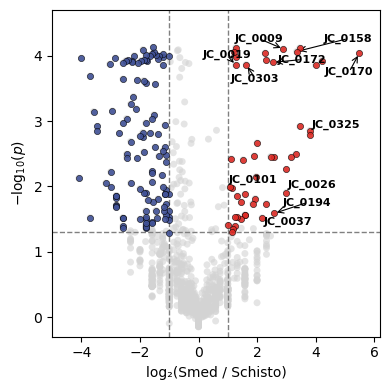

In [73]:
import numpy as np
from adjustText import adjust_text
import matplotlib.pyplot as plt

# --- data ---
x = df_enr_sorted["log2FC_schisto_over_Smed"]
neglogp = df_enr_sorted["-log10_p"]
motif_names = df_enr_sorted["motif"]

# jitter for display only (same length/order as df_enr_sorted)
rng = np.random.default_rng(0)
y_plot = neglogp + rng.uniform(-0.15, 0.15, size=neglogp.shape)

# --- thresholds ---
log2fc_thr = 1.0
p_thr = 0.05
neglogp_thr = -np.log10(p_thr)

# --- masks ---
sig = neglogp >= neglogp_thr
right_sig = sig & (x >= log2fc_thr)
left_sig  = sig & (x <= -log2fc_thr)

plt.figure(figsize=(4, 4))

# background
plt.scatter(
    x, y_plot,
    s=25, alpha=0.6,
    color="lightgrey",
    edgecolors="none",
    rasterized=True
)

# right significant
plt.scatter(
    x[right_sig], y_plot[right_sig],
    s=20, alpha=0.9,
    color="#de2c26",
    edgecolors="black",
    linewidths=0.4,
    zorder=5,
    rasterized=True
)

# left significant
plt.scatter(
    x[left_sig], y_plot[left_sig],
    s=20, alpha=0.9,
    color="#415297",
    edgecolors="black",
    linewidths=0.4,
    zorder=5,
    rasterized=True
)

# guide lines
plt.axhline(neglogp_thr, color="grey", linestyle="--", lw=1)
plt.axvline(log2fc_thr,  color="grey", linestyle="--", lw=1)
plt.axvline(-log2fc_thr, color="grey", linestyle="--", lw=1)

# ---- KEY FIX: use the jittered y values for the labels ----
# Make a quick lookup table of motif -> (x, y_jittered)
tmp = df_enr_sorted[["motif", "log2FC_schisto_over_Smed"]].copy()
tmp["y_jitter"] = y_plot.values
tmp = tmp.drop_duplicates("motif")  # just in case motif appears >1 time

motifs_to_label = ['JC_0009','JC_0019','JC_0026','JC_0037','JC_0101','JC_0158',
                   'JC_0170','JC_0172','JC_0194','JC_0303','JC_0325']

texts = []
for m in motifs_to_label:
    row = tmp.loc[tmp["motif"] == m]
    if not row.empty:
        row = row.iloc[0]
        texts.append(
            plt.text(
                row["log2FC_schisto_over_Smed"],
                row["y_jitter"],          # ⭐ use jittered y so it sits on the dot
                m,
                fontsize=8,
                weight="bold",
                color="black",
                zorder=10
            )
        )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color="black", lw=0.8),
    expand_points=(1.2, 1.2),
    expand_text=(1.1, 1.3),
    force_text=0.7,
    force_points=0.5
)

plt.xlabel("log₂(Smed / Schisto)")
plt.ylabel(r"$-\log_{10}(p)$")
plt.ylim([-0.3, 4.7])
plt.xlim([-5,6.2])
plt.tight_layout()
plt.savefig("./Figures/Figure6/Smed_peaks_schisto_model_motif_enrichment.svg",dpi=600)
plt.show()

### Making barplot to go along with volcano plot

In [31]:
neural_motifs = ['JC_0001|Pax2(0.321)', 'JC_0004|HCM1(0.290)', 'JC_0006|MOT2(0.189)', 'JC_0010|dl(0.000)', 'JC_0011|REL(0.162)', 'JC_0012|ELK3(0.088)', 'JC_0014|FOXI1(0.063)', 'JC_0018|HMG-I/Y(0.019)', 'JC_0022|MZF1(var.2)(0.000)', 'JC_0024|PAX6(0.000)', 'JC_0028|RREB1(0.047)', 'JC_0030|SOX8(0.153)', 'JC_0031|AP1(0.211)', 'JC_0032|RBPJ(0.338)', 'JC_0034|sma-4(0.237)', 'JC_0043|NFIX(var.2)(0.119)', 'JC_0046|abi4(0.000)', 'JC_0047|Dlx2(0.053)', 'JC_0050|ZNF354C(0.000)', 'JC_0054|EWSR1-FLI1(0.000)', 'JC_0058|AHL20(0.142)', 'JC_0062|PLAG1(0.000)', 'JC_0065|HOXC4(0.160)', 'JC_0066|NK7.1(0.157)', 'JC_0067|Lim1(0.115)', 'JC_0069|Lim3(0.213)', 'JC_0070|Deaf1(0.231)', 'JC_0071|oc(0.080)', 'JC_0072|schlank(0.000)', 'JC_0073|GATA3(0.177)', 'JC_0078|VDR(0.345)', 'JC_0079|exd(0.002)', 'JC_0080|onecut(0.099)', 'JC_0094|MIG3(0.096)', 'JC_0095|AFT2(0.045)', 'JC_0096|Foxn1(0.350)', 'JC_0099|CAT8(0.184)', 'JC_0101|AZF1(0.282)', 'JC_0105|STB4(0.223)', 'JC_0106|CHA4(0.393)', 'JC_0115|FZF1(0.000)', 'JC_0117|FOSL1(0.043)', 'JC_0118|MSN4(0.063)', 'JC_0123|NFYA(0.170)', 'JC_0129|MAC1(0.000)', 'JC_0130|HMRA1(0.000)', 'JC_0131|CMTA2(0.171)', 'JC_0136|RDS2(0.480)', 'JC_0141|PHD1(0.122)', 'JC_0142|PHO2(0.396)', 'JC_0147|RFX1(0.285)', 'JC_0150|RME1(0.000)', 'JC_0158|SPT23(0.000)', 'JC_0161|ERF069(0.129)', 'JC_0162|TFDP1(0.265)', 'JC_0165|TBF1(0.143)', 'JC_0166|TBS1(0.000)', 'JC_0170|XBP1(0.014)', 'JC_0172|YAP5(0.000)', 'JC_0178|hkb(0.398)', 'JC_0182|ZIC4(0.145)', 'JC_0184|ttk(0.000)', 'JC_0190|KLF11(0.157)', 'JC_0192|MEF2A(0.246)', 'JC_0193|BACH1(0.087)', 'JC_0197|SOX4(0.087)', 'JC_0211|blmp-1(0.450)', 'JC_0212|daf-12(0.028)', 'JC_0214|efl-1(0.127)', 'JC_0216|eor-1(0.028)', 'JC_0217|snpc-4(0.000)', 'JC_0218|MSC(0.281)', 'JC_0223|ABI3(0.269)', 'JC_0224|RAP2-3(0.191)', 'JC_0238|KLF4(0.340)', 'JC_0247|gcm2(0.054)', 'JC_0250|HNF1B(0.014)', 'JC_0255|POU4F3(0.087)', 'JC_0256|SPDEF(0.036)', 'JC_0257|SPIC(0.018)', 'JC_0263|PROP1(0.159)', 'JC_0264|Rarg(0.141)', 'JC_0266|EGR2(0.149)', 'JC_0272|E2F8(0.075)', 'JC_0275|NFKB2(0.067)', 'JC_0278|POU6F1(var.2)(0.077)', 'JC_0280|RFX2(0.147)', 'JC_0283|TFAP2C(var.3)(0.009)', 'JC_0294|Hmx1(0.140)', 'JC_0297|DREB1A(0.132)', 'JC_0303|PHYPADRAFT_140773(0.030)', 'JC_0305|ERF6(0.221)', 'JC_0306|GATA15(0.173)', 'JC_0315|GATA2(0.106)', 'JC_0318|RELB(0.265)', 'JC_0320|ZNF24(0.000)', 'JC_0324|IDD5(0.183)', 'JC_0325|SOL1(0.105)', 'JC_0331|AGL42(0.000)', 'JC_0348|AT2G40260(0.183)', 'JC_0349|BPC6(0.350)', 'JC_0350|BPC5(0.000)', 'JC_0352|RAMOSA1(0.000)', 'JC_0353|IRF3(0.049)', 'JC_0368|GABPA(0.103)', 'JC_0373|NR1D2(0.085)', 'JC_0381|VEZF1(0.259)', 'JC_0384|ZFP57(0.026)', 'JC_0389|ZNF274(0.048)', 'JC_0392|ZNF460(0.000)', 'JC_0393|ZNF528(0.000)', 'JC_0396|ZSCAN29(0.011)', 'JC_0397|EBF3(0.115)', 'JC_0401|Wt1(0.209)', 'JC_0407|SP2(0.077)', 'JC_0410|ZBTB14(0.000)', 'JC_0411|ZKSCAN5(0.125)', 'JC_0412|ZNF16(0.000)', 'JC_0414|ZNF449(0.029)', 'JC_0418|PRDM1(0.077)', 'JC_0420|ZNF263(0.094)', 'JC_0424|ARF36(0.235)', 'JC_0428|Clamp(0.000)', 'WC_0001|br(var.2)(1.940)', 'WC_0011|br(var.2)(3.450)', 'WC_0014|KLF4(2.356)', 'WC_0015|KLF4(1.263)', 'WC_0017|ZNF449(2.146)', 'WC_0018|Macho-1(2.557)', 'WC_0022|Macho-1(1.558)', 'WC_0031|KLF4(3.611)', 'WC_0036|Mecom(8.647)', 'WC_0037|ZNF354C(3.352)', 'WC_0045|GATA4(2.765)', 'WC_0047|CDC5(2.004)', 'WC_0054|REF6(5.173)', 'WC_0056|Stat5a(1.815)', 'WC_0061|DAL82(0.844)', 'WC_0074|Trl(5.433)', 'WC_0084|MEF2C(6.614)', 'WC_0098|AGL13(9.419)', 'WC_0102|SOX18(1.382)', 'WC_0105|OSR1(4.612)', 'WC_0107|ERF069(0.693)', 'WC_0113|THAP1(2.879)', 'WC_0116|ZNF449(3.448)', 'WC_0121|DOF5.3(1.591)', 'WC_0122|rst2(2.776)', 'WC_0149|RAMOSA1(4.353)', 'WC_0169|daf-12(3.532)', 'WC_0171|ZNF24(3.555)', 'WC_0174|MSANTD3(2.310)', 'WC_0175|Nkx2-5(var.2)(4.465)', 'WC_0181|NR2F1(4.283)', 'WC_0185|GATA1(1.562)', 'WC_0193|EGR1(3.089)', 'WC_0194|NFIX(2.497)', 'WC_0201|NFATC1(1.093)', 'WC_0226|SOX15(0.799)', 'WC_0232|KLF4(2.482)', 'WC_0247|SPL11(5.108)', 'WC_0271|cre-1(1.589)', 'WC_0282|ZNF24(3.836)', 'WC_0285|OSR1(5.350)', 'WC_0288|SP9(4.756)', 'WC_0294|HAP3(4.090)', 'WC_0324|ZNF682(6.893)', 'WC_0334|KLF2(3.176)', 'WC_0335|SUT1(4.518)', 'WC_0351|KLF4(2.167)', 'WC_0383|HOXB13(2.591)', 'WC_0386|Clamp(2.490)', 'WC_0394|ERF098(0.481)', 'WC_0398|NHP6B(1.711)', 'WC_0400|TBF1(6.209)', 'WC_0405|DOF5.7(2.394)', 'WC_0410|KLF4(3.070)', 'WC_0412|ceh-48(2.558)', 'WC_0416|ZNF740(3.308)', 'WC_0423|ZNF384(2.399)', 'WC_0469|MEF2A(1.102)', 'WC_0470|DOF2.4(1.076)', 'WC_0472|ZNF148(2.996)', 'WC_0474|NFYA(4.033)', 'WC_0475|BIM1(1.627)', 'WC_0478|ZNF449(5.846)', 'WC_0484|MEF2A(2.775)', 'WC_0485|VEZF1(4.789)', 'WC_0486|AHL20(3.033)', 'WC_0491|MEF2A(3.821)', 'WC_0496|REF6(6.031)', 'WC_0503|Wt1(4.723)', 'WC_0509|br(var.2)(3.417)', 'WC_0511|br(var.2)(3.488)', 'WC_0514|Trl(1.901)', 'WC_0515|GATA15(0.771)', 'WC_0519|FHY3(3.839)', 'WC_0521|ZNF740(2.385)', 'WC_0524|br(var.2)(4.005)', 'WC_0529|Trl(2.269)', 'WC_0542|KLF4(1.630)', 'WC_0551|Trl(4.081)', 'WC_0565|Trl(2.451)', 'WC_0572|THAP1(1.040)', 'WC_0575|TBF1(2.074)', 'WC_0578|ZBTB32(6.563)', 'WC_0589|MSN2(1.803)', 'WC_0590|NFYB(3.331)', 'WC_0597|NFYA(4.447)', 'WC_0602|Trl(4.135)', 'WC_0607|TEAD2(1.510)', 'WC_0611|KLF4(1.638)', 'WC_0612|THAP1(2.351)', 'WC_0613|TCF12(var.2)(2.934)', 'WC_0614|KLF4(2.548)', 'WC_0618|Trl(2.877)', 'WC_0626|Trl(3.834)', 'WC_0629|ZNF148(5.621)', 'WC_0632|ELF1(6.156)', 'WC_0645|NFYC(2.101)', 'WC_0646|ZNF449(5.013)', 'WC_0647|VEZF1(2.728)', 'WC_0648|KLF4(3.372)', 'WC_0650|MSN2(2.271)', 'WC_0651|br(var.2)(1.279)', 'WC_0677|NFYB(4.801)', 'WC_0719|StBRC1(1.323)', 'WC_0721|NFYB(4.790)', 'WC_0722|NFYA(4.071)', 'WC_0724|E2F6(4.449)', 'WC_0725|E2F6(2.941)', 'WC_0727|ZNF449(3.866)', 'WC_0747|Nkx2-5(var.2)(6.042)', 'WC_0754|NR2F1(7.802)', 'WC_0755|Trl(3.108)', 'WC_0761|NFYB(6.883)', 'WC_0765|ZBTB33(7.467)', 'WC_0781|ZNF384(1.164)', 'WC_0782|Trl(4.601)', 'WC_0786|Trl(4.941)', 'WC_0794|HINFP(8.515)', 'WC_0823|KLF4(1.552)', 'WC_0825|Trl(3.675)', 'WC_0826|GATA15(3.109)', 'WC_0827|SPL4(2.538)', 'WC_0855|daf-12(4.585)', 'WC_0856|MSN2(3.143)', 'WC_0885|EGR1(3.003)', 'WC_0908|br(var.2)(2.322)', 'WC_0912|DOF2.4(0.430)', 'WC_0919|twi(1.894)', 'WC_0920|EGR4(3.454)', 'WC_0921|DOF2.4(0.809)', 'WC_0925|Ahr--Arnt(1.103)', 'WC_0928|DMRTA2(2.532)', 'WC_0948|T11I18.17(3.324)', 'WC_0962|ERF098(1.418)', 'WC_0966|POU5F1(1.526)', 'WC_0968|ERF098(0.849)', 'WC_0969|HAP2(1.146)', 'WC_0975|twi(3.350)', 'WC_0976|HAP5(4.272)', 'WC_0977|HAP3(4.769)', 'WC_0979|NFATC1(0.852)', 'WC_0992|FUS3(3.073)', 'WC_0993|twi(1.697)', 'WC_0996|NHP6B(3.022)', 'WC_0997|MYB3(3.397)', 'WC_1010|FOSL1--JUNB(0.804)', 'WC_1011|ABI3(1.217)', 'WC_1013|JUNB(0.981)', 'WC_1024|NFIC(5.573)', 'WC_1033|twi(1.486)', 'WC_1071|br(var.2)(3.839)', 'WC_1078|ONECUT3(3.340)', 'WC_1091|eor-1(2.824)', 'WC_1093|SPI1(2.470)', 'WC_1114|daf-12(2.799)', 'WC_1125|ONECUT1(2.067)', 'WC_1134|EGR4(4.201)', 'WC_1156|ZNF384(2.418)', 'WC_1159|Trl(3.919)', 'WC_1174|RFX4(1.240)', 'WC_1176|BACH1(4.120)', 'WC_1236|ZHD6(2.429)', 'WC_1240|ABI3(0.466)', 'WC_1243|SPT15(4.306)', 'WC_1252|AT5G02460(5.535)', 'WC_1253|unc-62(2.014)', 'WC_1256|ZKSCAN1(5.754)', 'WC_1260|daf-12(4.167)', 'WC_1290|PHD1(1.097)', 'WC_1292|NFYC(1.120)', 'WC_1294|MYOG(0.992)', 'WC_1302|ARF27(2.872)', 'WC_1309|Foxl2(3.276)', 'WC_1367|NFATC3(0.894)', 'WC_1374|NFYA(3.991)', 'WC_1383|HAP5(8.588)', 'WC_1384|SPI1(3.724)', 'WC_1455|DAL82(1.653)', 'WC_1458|SOK2(2.317)', 'WC_1460|MAFF(6.378)', 'WC_1470|MSANTD3(1.512)', 'WC_1485|ZNF410(8.859)', 'WC_1496|BPC1(5.533)', 'WC_1518|ZHD6(3.373)', 'WC_1527|ASCL1(var.2)(6.131)', 'WC_1528|daf-12(5.305)', 'WC_1565|FUS3(4.424)', 'WC_1573|HAP3(3.031)', 'WC_1574|ATHB-5(4.011)', 'WC_1576|Dmrt1(5.707)', 'WC_1590|NHP6B(3.405)', 'WC_1641|AT2G40260(4.183)', 'WC_1645|AHL12(3.240)', 'WC_1648|MSANTD3(2.888)', 'WC_1653|Isl1(6.300)', 'WC_1692|TBX20(6.056)', 'WC_1694|wc-1(8.600)', 'WC_1784|RFX5(3.271)', 'WC_1796|daf-12(5.646)', 'WC_1799|pho(3.241)', 'WC_1803|NFYA(3.897)', 'WC_1917|daf-12(3.496)', 'WC_1919|Dux(6.388)', 'WC_1955|HAP3(8.269)', 'WC_1968|ASCL1(var.2)(6.373)', 'WC_1969|ZNF740(5.008)', 'WC_1970|ZNF460(5.054)', 'WC_1973|ZNF148(1.330)', 'WC_1974|ZNF740(6.457)', 'WC_1977|Trl(4.401)', 'WC_2006|BATF3(4.894)']

In [32]:
Smed_neural = ['JC_0002|br(0.006)',
 'JC_0004|HCM1(0.290)',
 'JC_0010|dl(0.000)',
 'JC_0011|REL(0.162)',
 'JC_0012|ELK3(0.088)',
 'JC_0019|ZNF384(0.534)',
 'JC_0020|STAT1--STAT2(0.618)',
 'JC_0022|MZF1(var.2)(0.000)',
 'JC_0028|RREB1(0.047)',
 'JC_0030|SOX8(0.153)',
 'JC_0031|AP1(0.211)',
 'JC_0032|RBPJ(0.338)',
 'JC_0034|sma-4(0.237)',
 'JC_0043|NFIX(var.2)(0.119)',
 'JC_0044|id1(0.523)',
 'JC_0046|abi4(0.000)',
 'JC_0047|Dlx2(0.053)',
 'JC_0050|ZNF354C(0.000)',
 'JC_0051|HDG1(0.256)',
 'JC_0053|Pou5f1--Sox2(0.000)',
 'JC_0054|EWSR1-FLI1(0.000)',
 'JC_0058|AHL20(0.142)',
 'JC_0059|NFATC1(0.123)',
 'JC_0060|INSM1(0.000)',
 'JC_0062|PLAG1(0.000)',
 'JC_0063|Nr2e3(0.000)',
 'JC_0064|HOXD9(0.138)',
 'JC_0065|HOXC4(0.160)',
 'JC_0066|NK7.1(0.157)',
 'JC_0067|Lim1(0.115)',
 'JC_0069|Lim3(0.213)',
 'JC_0071|oc(0.080)',
 'JC_0072|schlank(0.000)',
 'JC_0075|vis(0.107)',
 'JC_0077|brk(0.399)',
 'JC_0080|onecut(0.099)',
 'JC_0081|KAN1(0.200)',
 'JC_0084|vvl(0.198)',
 'JC_0087|GCR2(0.427)',
 'JC_0088|lin-14(0.197)',
 'JC_0091|ABF1(0.039)',
 'JC_0094|MIG3(0.096)',
 'JC_0095|AFT2(0.045)',
 'JC_0099|CAT8(0.184)',
 'JC_0101|AZF1(0.282)',
 'JC_0105|STB4(0.223)',
 'JC_0106|CHA4(0.393)',
 'JC_0109|CUP2(0.000)',
 'JC_0117|FOSL1(0.043)',
 'JC_0118|MSN4(0.063)',
 'JC_0119|STB5(0.335)',
 'JC_0121|HAP1(0.234)',
 'JC_0123|NFYA(0.170)',
 'JC_0129|MAC1(0.000)',
 'JC_0130|HMRA1(0.000)',
 'JC_0136|RDS2(0.480)',
 'JC_0141|PHD1(0.122)',
 'JC_0142|PHO2(0.396)',
 'JC_0147|RFX1(0.285)',
 'JC_0148|RGT1(0.305)',
 'JC_0149|RLM1(0.010)',
 'JC_0150|RME1(0.000)',
 'JC_0151|ROX1(0.000)',
 'JC_0153|OSR2(0.428)',
 'JC_0154|SFP1(0.222)',
 'JC_0157|SPT2(0.000)',
 'JC_0159|STB3(0.049)',
 'JC_0160|PRDM4(0.281)',
 'JC_0162|TFDP1(0.265)',
 'JC_0163|SUT2(0.153)',
 'JC_0165|TBF1(0.143)',
 'JC_0167|THI2(0.000)',
 'JC_0178|hkb(0.398)',
 'JC_0181|OSR1(0.114)',
 'JC_0184|ttk(0.000)',
 'JC_0188|Gfi1b(0.144)',
 'JC_0189|FOSL2--JUNB(var.2)(0.107)',
 'JC_0190|KLF11(0.157)',
 'JC_0192|MEF2A(0.246)',
 'JC_0193|BACH1(0.087)',
 'JC_0195|NRF1(0.000)',
 'JC_0197|SOX4(0.087)',
 'JC_0203|GATA1--TAL1(0.023)',
 'JC_0209|pan(0.000)',
 'JC_0210|BEAF-32(0.248)',
 'JC_0211|blmp-1(0.450)',
 'JC_0212|daf-12(0.028)',
 'JC_0213|dpy-27(0.000)',
 'JC_0214|efl-1(0.127)',
 'JC_0216|eor-1(0.028)',
 'JC_0217|snpc-4(0.000)',
 'JC_0220|AGL16(0.267)',
 'JC_0223|ABI3(0.269)',
 'JC_0224|RAP2-3(0.191)',
 'JC_0226|ATHB-51(0.178)',
 'JC_0230|CDC5(0.049)',
 'JC_0238|KLF4(0.340)',
 'JC_0250|HNF1B(0.014)',
 'JC_0251|HOXC11(0.096)',
 'JC_0255|POU4F3(0.087)',
 'JC_0256|SPDEF(0.036)',
 'JC_0257|SPIC(0.018)',
 'JC_0263|PROP1(0.159)',
 'JC_0266|EGR2(0.149)',
 'JC_0268|ZBED1(0.000)',
 'JC_0270|ZNF410(0.027)',
 'JC_0272|E2F8(0.075)',
 'JC_0275|NFKB2(0.067)',
 'JC_0278|POU6F1(var.2)(0.077)',
 'JC_0280|RFX2(0.147)',
 'JC_0283|TFAP2C(var.3)(0.009)',
 'JC_0285|Mafb(0.114)',
 'JC_0291|Sox1(0.279)',
 'JC_0292|Sox11(0.000)',
 'JC_0294|Hmx1(0.140)',
 'JC_0296|NAC058(0.077)',
 'JC_0297|DREB1A(0.132)',
 'JC_0298|ARF8(0.140)',
 'JC_0301|BHLH112(0.101)',
 'JC_0302|LHY1(0.037)',
 'JC_0303|PHYPADRAFT_140773(0.030)',
 'JC_0304|DREB2C(0.094)',
 'JC_0305|ERF6(0.221)',
 'JC_0307|EFM(0.179)',
 'JC_0316|MYB(0.055)',
 'JC_0318|RELB(0.265)',
 'JC_0319|SIX1(0.034)',
 'JC_0320|ZNF24(0.000)',
 'JC_0321|ZNF282(0.022)',
 'JC_0324|IDD5(0.183)',
 'JC_0328|MYB119(0.058)',
 'JC_0329|MYB113(0.408)',
 'JC_0330|At5g58900(0.172)',
 'JC_0331|AGL42(0.000)',
 'JC_0335|AT2G33710(0.176)',
 'JC_0337|PLT3(0.171)',
 'JC_0346|AT1G76870(0.042)',
 'JC_0347|STZ(0.249)',
 'JC_0348|AT2G40260(0.183)',
 'JC_0349|BPC6(0.350)',
 'JC_0350|BPC5(0.000)',
 'JC_0351|REF6(0.000)',
 'JC_0352|RAMOSA1(0.000)',
 'JC_0353|IRF3(0.049)',
 'JC_0358|ZBTB26(0.195)',
 'JC_0362|BARX2(0.010)',
 'JC_0368|GABPA(0.103)',
 'JC_0372|NHLH2(0.040)',
 'JC_0373|NR1D2(0.085)',
 'JC_0377|SOX14(0.213)',
 'JC_0378|SOX18(0.038)',
 'JC_0381|VEZF1(0.259)',
 'JC_0383|ZBTB6(0.042)',
 'JC_0388|ZNF140(0.000)',
 'JC_0389|ZNF274(0.048)',
 'JC_0390|ZNF317(0.073)',
 'JC_0392|ZNF460(0.000)',
 'JC_0393|ZNF528(0.000)',
 'JC_0396|ZSCAN29(0.011)',
 'JC_0397|EBF3(0.115)',
 'JC_0401|Wt1(0.209)',
 'JC_0403|MXI1(0.153)',
 'JC_0407|SP2(0.077)',
 'JC_0410|ZBTB14(0.000)',
 'JC_0411|ZKSCAN5(0.125)',
 'JC_0412|ZNF16(0.000)',
 'JC_0414|ZNF449(0.029)',
 'JC_0416|NAC078(0.076)',
 'JC_0418|PRDM1(0.077)',
 'JC_0420|ZNF263(0.094)',
 'JC_0424|ARF36(0.235)',
 'JC_0427|ARF34(0.255)',
 'JC_0428|Clamp(0.000)',
 'WC_0001|br(var.2)(1.940)',
 'WC_0005|RSC3(0.717)',
 'WC_0006|SKN7(1.145)',
 'WC_0009|z(0.845)',
 'WC_0011|br(var.2)(3.450)',
 'WC_0013|REL(2.463)',
 'WC_0014|KLF4(2.356)',
 'WC_0015|KLF4(1.263)',
 'WC_0017|ZNF449(2.146)',
 'WC_0018|Macho-1(2.557)',
 'WC_0019|Stat92E(5.245)',
 'WC_0022|Macho-1(1.558)',
 'WC_0023|ZBTB32(5.464)',
 'WC_0029|Foxj3(6.975)',
 'WC_0031|KLF4(3.611)',
 'WC_0033|NR2C1(1.613)',
 'WC_0035|odd(5.868)',
 'WC_0036|Mecom(8.647)',
 'WC_0037|ZNF354C(3.352)',
 'WC_0040|AT-GTL1(4.787)',
 'WC_0045|GATA4(2.765)',
 'WC_0047|CDC5(2.004)',
 'WC_0049|RSC3(0.641)',
 'WC_0054|REF6(5.173)',
 'WC_0055|z(2.461)',
 'WC_0056|Stat5a(1.815)',
 'WC_0059|SRY(1.929)',
 'WC_0074|Trl(5.433)',
 'WC_0083|DOF2.4(0.904)',
 'WC_0084|MEF2C(6.614)',
 'WC_0098|AGL13(9.419)',
 'WC_0101|RSC3(1.010)',
 'WC_0105|OSR1(4.612)',
 'WC_0107|ERF069(0.693)',
 'WC_0108|SPL7(5.733)',
 'WC_0113|THAP1(2.879)',
 'WC_0116|ZNF449(3.448)',
 'WC_0117|MIG2(2.502)',
 'WC_0120|MEF2D(4.021)',
 'WC_0121|DOF5.3(1.591)',
 'WC_0122|rst2(2.776)',
 'WC_0149|RAMOSA1(4.353)',
 'WC_0167|TSAR2(5.535)',
 'WC_0168|ZNF382(7.410)',
 'WC_0169|daf-12(3.532)',
 'WC_0171|ZNF24(3.555)',
 'WC_0173|AHL20(1.684)',
 'WC_0174|MSANTD3(2.310)',
 'WC_0175|Nkx2-5(var.2)(4.465)',
 'WC_0181|NR2F1(4.283)',
 'WC_0185|GATA1(1.562)',
 'WC_0190|RGM1(2.786)',
 'WC_0193|EGR1(3.089)',
 'WC_0194|NFIX(2.497)',
 'WC_0196|fkh-9(3.878)',
 'WC_0197|br(var.2)(3.753)',
 'WC_0201|NFATC1(1.093)',
 'WC_0207|REF6(8.763)',
 'WC_0210|D(7.718)',
 'WC_0219|HSFA6B(8.419)',
 'WC_0226|SOX15(0.799)',
 'WC_0228|CDC5(3.008)',
 'WC_0232|KLF4(2.482)',
 'WC_0235|CDF2(3.258)',
 'WC_0237|ZNF384(1.200)',
 'WC_0247|SPL11(5.108)',
 'WC_0263|MEF2A(8.104)',
 'WC_0271|cre-1(1.589)',
 'WC_0273|LIN54(1.479)',
 'WC_0277|TBF1(4.442)',
 'WC_0282|ZNF24(3.836)',
 'WC_0283|WRKY11(5.670)',
 'WC_0285|OSR1(5.350)',
 'WC_0288|SP9(4.756)',
 'WC_0289|Plagl1(3.593)',
 'WC_0294|HAP3(4.090)',
 'WC_0298|LIN54(7.164)',
 'WC_0334|KLF2(3.176)',
 'WC_0335|SUT1(4.518)',
 'WC_0351|KLF4(2.167)',
 'WC_0376|SGR5(4.018)',
 'WC_0379|NFYA(8.367)',
 'WC_0383|HOXB13(2.591)',
 'WC_0386|Clamp(2.490)',
 'WC_0395|HOXA9(1.938)',
 'WC_0396|HOXA10(3.610)',
 'WC_0397|CDX1(7.007)',
 'WC_0398|NHP6B(1.711)',
 'WC_0400|TBF1(6.209)',
 'WC_0405|DOF5.7(2.394)',
 'WC_0406|MEF2A(5.236)',
 'WC_0409|HAP3(7.112)',
 'WC_0410|KLF4(3.070)',
 'WC_0412|ceh-48(2.558)',
 'WC_0416|ZNF740(3.308)',
 'WC_0423|ZNF384(2.399)',
 'WC_0432|HAP5(8.314)',
 'WC_0462|YAP6(7.607)',
 'WC_0469|MEF2A(1.102)',
 'WC_0470|DOF2.4(1.076)',
 'WC_0472|ZNF148(2.996)',
 'WC_0474|NFYA(4.033)',
 'WC_0475|BIM1(1.627)',
 'WC_0478|ZNF449(5.846)',
 'WC_0479|Hmx2(5.764)',
 'WC_0484|MEF2A(2.775)',
 'WC_0485|VEZF1(4.789)',
 'WC_0486|AHL20(3.033)',
 'WC_0489|Zfx(5.726)',
 'WC_0491|MEF2A(3.821)',
 'WC_0496|REF6(6.031)',
 'WC_0497|AT1G76870(5.370)',
 'WC_0500|STAT1(3.533)',
 'WC_0503|Wt1(4.723)',
 'WC_0509|br(var.2)(3.417)',
 'WC_0511|br(var.2)(3.488)',
 'WC_0514|Trl(1.901)',
 'WC_0515|GATA15(0.771)',
 'WC_0518|SPL7(4.206)',
 'WC_0519|FHY3(3.839)',
 'WC_0521|ZNF740(2.385)',
 'WC_0524|br(var.2)(4.005)',
 'WC_0529|Trl(2.269)',
 'WC_0537|LCL1(9.148)',
 'WC_0540|PHOX2B(2.856)',
 'WC_0542|KLF4(1.630)',
 'WC_0543|RSC30(2.574)',
 'WC_0551|Trl(4.081)',
 'WC_0565|Trl(2.451)',
 'WC_0569|RLM1(6.962)',
 'WC_0572|THAP1(1.040)',
 'WC_0574|z(2.885)',
 'WC_0575|TBF1(2.074)',
 'WC_0577|ARR11(8.166)',
 'WC_0578|ZBTB32(6.563)',
 'WC_0589|MSN2(1.803)',
 'WC_0590|NFYB(3.331)',
 'WC_0596|SPL4(1.088)',
 'WC_0597|NFYA(4.447)',
 'WC_0599|MEF2C(4.348)',
 'WC_0602|Trl(4.135)',
 'WC_0607|TEAD2(1.510)',
 'WC_0609|MEF2D(4.938)',
 'WC_0611|KLF4(1.638)',
 'WC_0612|THAP1(2.351)',
 'WC_0613|TCF12(var.2)(2.934)',
 'WC_0614|KLF4(2.548)',
 'WC_0618|Trl(2.877)',
 'WC_0621|NFYA(6.860)',
 'WC_0626|Trl(3.834)',
 'WC_0629|ZNF148(5.621)',
 'WC_0632|ELF1(6.156)',
 'WC_0645|NFYC(2.101)',
 'WC_0646|ZNF449(5.013)',
 'WC_0647|VEZF1(2.728)',
 'WC_0648|KLF4(3.372)',
 'WC_0650|MSN2(2.271)',
 'WC_0651|br(var.2)(1.279)',
 'WC_0677|NFYB(4.801)',
 'WC_0719|StBRC1(1.323)',
 'WC_0721|NFYB(4.790)',
 'WC_0722|NFYA(4.071)',
 'WC_0723|ZNF384(1.666)',
 'WC_0724|E2F6(4.449)',
 'WC_0725|E2F6(2.941)',
 'WC_0727|ZNF449(3.866)',
 'WC_0738|MSANTD3(3.772)',
 'WC_0747|Nkx2-5(var.2)(6.042)',
 'WC_0749|br(var.2)(3.570)',
 'WC_0754|NR2F1(7.802)',
 'WC_0755|Trl(3.108)',
 'WC_0758|NFYB(6.399)',
 'WC_0761|NFYB(6.883)',
 'WC_0765|ZBTB33(7.467)',
 'WC_0781|ZNF384(1.164)',
 'WC_0782|Trl(4.601)',
 'WC_0784|GATA4(6.752)',
 'WC_0785|Stat92E(1.643)',
 'WC_0786|Trl(4.941)',
 'WC_0794|HINFP(8.515)',
 'WC_0823|KLF4(1.552)',
 'WC_0825|Trl(3.675)',
 'WC_0826|GATA15(3.109)',
 'WC_0827|SPL4(2.538)',
 'WC_0854|BAS1(3.975)',
 'WC_0855|daf-12(4.585)',
 'WC_0856|MSN2(3.143)',
 'WC_0882|ZIC3(6.464)',
 'WC_0885|EGR1(3.003)',
 'WC_0908|br(var.2)(2.322)',
 'WC_0912|DOF2.4(0.430)',
 'WC_0919|twi(1.894)',
 'WC_0920|EGR4(3.454)',
 'WC_0921|DOF2.4(0.809)',
 'WC_0922|PHYPADRAFT_140773(2.422)',
 'WC_0925|Ahr--Arnt(1.103)',
 'WC_0928|DMRTA2(2.532)',
 'WC_0931|NFYA(3.441)',
 'WC_0932|EGR2(4.300)',
 'WC_0944|TBX3(1.343)',
 'WC_0948|T11I18.17(3.324)',
 'WC_0963|ZNF384(0.567)',
 'WC_0968|ERF098(0.849)',
 'WC_0969|HAP2(1.146)',
 'WC_0971|PHYPADRAFT_38837(1.271)',
 'WC_0975|twi(3.350)',
 'WC_0976|HAP5(4.272)',
 'WC_0977|HAP3(4.769)',
 'WC_0978|ARF27(2.514)',
 'WC_0979|NFATC1(0.852)',
 'WC_0980|odd(7.241)',
 'WC_0992|FUS3(3.073)',
 'WC_0993|twi(1.697)',
 'WC_0996|NHP6B(3.022)',
 'WC_0997|MYB3(3.397)',
 'WC_1010|FOSL1--JUNB(0.804)',
 'WC_1011|ABI3(1.217)',
 'WC_1012|EGR4(1.928)',
 'WC_1013|JUNB(0.981)',
 'WC_1019|HAP5(6.244)',
 'WC_1024|NFIC(5.573)',
 'WC_1039|NFYB(4.754)',
 'WC_1044|MAFG(5.860)',
 'WC_1068|RAP1(4.505)',
 'WC_1071|br(var.2)(3.839)',
 'WC_1072|HNF4A(var.2)(5.939)',
 'WC_1079|ZNF384(1.549)',
 'WC_1088|POU5F1(2.123)',
 'WC_1091|eor-1(2.824)',
 'WC_1093|SPI1(2.470)',
 'WC_1097|NFYB(2.176)',
 'WC_1114|daf-12(2.799)',
 'WC_1132|Cf2(2.076)',
 'WC_1142|ZSCAN4(4.794)',
 'WC_1145|ATHB-5(7.384)',
 'WC_1147|ZNF24(6.483)',
 'WC_1154|ARF18(4.146)',
 'WC_1156|ZNF384(2.418)',
 'WC_1159|Trl(3.919)',
 'WC_1174|RFX4(1.240)',
 'WC_1176|BACH1(4.120)',
 'WC_1219|TFAP4(0.410)',
 'WC_1234|TCX3(1.522)',
 'WC_1236|ZHD6(2.429)',
 'WC_1240|ABI3(0.466)',
 'WC_1243|SPT15(4.306)',
 'WC_1245|z(1.798)',
 'WC_1246|ZHD6(3.821)',
 'WC_1251|SGR5(4.937)',
 'WC_1252|AT5G02460(5.535)',
 'WC_1254|HAT2(2.780)',
 'WC_1256|ZKSCAN1(5.754)',
 'WC_1257|ARF27(4.222)',
 'WC_1281|MEIS1(0.714)',
 'WC_1292|NFYC(1.120)',
 'WC_1296|FOXB1(2.639)',
 'WC_1302|ARF27(2.872)',
 'WC_1307|FKH1(6.210)',
 'WC_1309|Foxl2(3.276)',
 'WC_1316|NFYA(5.246)',
 'WC_1337|PHOX2B(5.782)',
 'WC_1352|MYOG(0.909)',
 'WC_1367|NFATC3(0.894)',
 'WC_1369|SOX9(1.590)',
 'WC_1374|NFYA(3.991)',
 'WC_1376|PHYPADRAFT_72483(1.233)',
 'WC_1378|SPL8(4.298)',
 'WC_1380|XBP1(1.075)',
 'WC_1382|Nkx3-2(3.170)',
 'WC_1384|SPI1(3.724)',
 'WC_1389|Arid5a(4.969)',
 'WC_1390|MYB(2.145)',
 'WC_1391|USF1(5.463)',
 'WC_1396|MYB(2.555)',
 'WC_1414|NFYC(3.344)',
 'WC_1417|ERF069(2.138)',
 'WC_1420|TRP2(7.464)',
 'WC_1450|ABI3(1.399)',
 'WC_1457|T11I18.17(2.508)',
 'WC_1458|SOK2(2.317)',
 'WC_1460|MAFF(6.378)',
 'WC_1470|MSANTD3(1.512)',
 'WC_1471|ONECUT1(3.469)',
 'WC_1474|ABI3(3.718)',
 'WC_1476|ERF069(1.360)',
 'WC_1477|MITF(4.178)',
 'WC_1480|CEBPD(6.105)',
 'WC_1485|ZNF410(8.859)',
 'WC_1489|FOXB1(3.203)',
 'WC_1490|MYB113(5.742)',
 'WC_1491|SRY(3.928)',
 'WC_1494|FUS3(6.516)',
 'WC_1496|BPC1(5.533)',
 'WC_1521|KLF9(5.112)',
 'WC_1527|ASCL1(var.2)(6.131)',
 'WC_1528|daf-12(5.305)',
 'WC_1531|ERF6(2.846)',
 'WC_1533|MYOG(3.582)',
 'WC_1545|POU5F1(5.094)',
 'WC_1557|PRDM1(1.054)',
 'WC_1560|FUS3(3.686)',
 'WC_1565|FUS3(4.424)',
 'WC_1567|Pdp1(5.257)',
 'WC_1573|HAP3(3.031)',
 'WC_1574|ATHB-5(4.011)',
 'WC_1575|NFYC(3.787)',
 'WC_1576|Dmrt1(5.707)',
 'WC_1590|NHP6B(3.405)',
 'WC_1613|pqm-1(8.544)',
 'WC_1637|FOXA1(2.514)',
 'WC_1638|FUS3(4.346)',
 'WC_1640|SFP1(3.554)',
 'WC_1641|AT2G40260(4.183)',
 'WC_1642|Foxf1(3.532)',
 'WC_1643|ARF27(3.880)',
 'WC_1645|AHL12(3.240)',
 'WC_1648|MSANTD3(2.888)',
 'WC_1653|Isl1(6.300)',
 'WC_1654|Hic1(3.364)',
 'WC_1655|achi(3.754)',
 'WC_1684|MEIS2(1.988)',
 'WC_1685|HAP2(1.320)',
 'WC_1686|RFX1(5.255)',
 'WC_1687|ERF021(4.949)',
 'WC_1688|ATHB15(7.361)',
 'WC_1691|ABF4(6.961)',
 'WC_1692|TBX20(6.056)',
 'WC_1698|ERF8(3.580)',
 'WC_1705|ZSCAN4(5.769)',
 'WC_1711|Zic1--Zic2(3.418)',
 'WC_1732|NFYB(5.938)',
 'WC_1745|HMRA1(6.057)',
 'WC_1749|TEAD2(5.118)',
 'WC_1757|ABI3(1.206)',
 'WC_1771|HAP3(7.053)',
 'WC_1778|ERF8(1.580)',
 'WC_1781|M1BP(5.143)',
 'WC_1784|RFX5(3.271)',
 'WC_1786|slp1(2.622)',
 'WC_1787|ABI3(7.190)',
 'WC_1788|ZBTB14(3.901)',
 'WC_1794|ABR1(3.268)',
 'WC_1795|Ascl2(5.571)',
 'WC_1796|daf-12(5.646)',
 'WC_1797|Stat2(6.638)',
 'WC_1798|MYB(0.694)',
 'WC_1799|pho(3.241)',
 'WC_1803|NFYA(3.897)',
 'WC_1804|NKX2-2(4.137)',
 'WC_1805|NFYA(6.797)',
 'WC_1806|ABI3(3.884)',
 'WC_1807|HAP3(5.615)',
 'WC_1808|Zic2(4.824)',
 'WC_1811|HAP3(5.686)',
 'WC_1813|TCF3(3.741)',
 'WC_1826|NKX2-5(1.877)',
 'WC_1828|STZ(1.517)',
 'WC_1877|MEIS3(0.965)',
 'WC_1892|NFYC(7.964)',
 'WC_1906|ERF069(1.646)',
 'WC_1907|MEIS2(4.249)',
 'WC_1908|M1BP(4.669)',
 'WC_1912|MAFG(5.294)',
 'WC_1914|RAP2-1(2.570)',
 'WC_1916|RAP211(4.683)',
 'WC_1917|daf-12(3.496)',
 'WC_1918|MYOG(4.270)',
 'WC_1919|Dux(6.388)',
 'WC_1922|JUND(3.469)',
 'WC_1931|DREB1B(5.213)',
 'WC_1938|CCA1(2.222)',
 'WC_1941|ATHB-5(4.328)',
 'WC_1955|HAP3(8.269)',
 'WC_1967|SFP1(2.967)',
 'WC_1968|ASCL1(var.2)(6.373)',
 'WC_1969|ZNF740(5.008)',
 'WC_1970|ZNF460(5.054)',
 'WC_1972|ERF096(4.233)',
 'WC_1973|ZNF148(1.330)',
 'WC_1974|ZNF740(6.457)',
 'WC_1975|ABI3(4.164)',
 'WC_1976|ARF34(4.373)',
 'WC_1977|Trl(4.401)',
 'WC_2000|SRY(2.735)',
 'WC_2042|PBX1(3.504)',
 'WC_2050|ZSCAN4(5.930)']

In [33]:
schisto_neural = ['JC_0001|Pax2(0.321)',
 'JC_0006|MOT2(0.189)',
 'JC_0009|PBF(0.050)',
 'JC_0010|dl(0.000)',
 'JC_0011|REL(0.162)',
 'JC_0012|ELK3(0.088)',
 'JC_0013|Mecom(0.000)',
 'JC_0015|Gam1(0.284)',
 'JC_0017|HMG-1(0.000)',
 'JC_0018|HMG-I/Y(0.019)',
 'JC_0019|ZNF384(0.534)',
 'JC_0020|STAT1--STAT2(0.618)',
 'JC_0022|MZF1(var.2)(0.000)',
 'JC_0023|ESR2(0.324)',
 'JC_0024|PAX6(0.000)',
 'JC_0026|NR2C1(0.176)',
 'JC_0028|RREB1(0.047)',
 'JC_0030|SOX8(0.153)',
 'JC_0031|AP1(0.211)',
 'JC_0032|RBPJ(0.338)',
 'JC_0034|sma-4(0.237)',
 'JC_0037|NHP6A(0.585)',
 'JC_0042|Macho-1(0.349)',
 'JC_0043|NFIX(var.2)(0.119)',
 'JC_0045|ARR18(0.228)',
 'JC_0046|abi4(0.000)',
 'JC_0050|ZNF354C(0.000)',
 'JC_0054|EWSR1-FLI1(0.000)',
 'JC_0058|AHL20(0.142)',
 'JC_0059|NFATC1(0.123)',
 'JC_0060|INSM1(0.000)',
 'JC_0061|RARA(var.2)(0.372)',
 'JC_0062|PLAG1(0.000)',
 'JC_0063|Nr2e3(0.000)',
 'JC_0071|oc(0.080)',
 'JC_0072|schlank(0.000)',
 'JC_0075|vis(0.107)',
 'JC_0084|vvl(0.198)',
 'JC_0086|SOHLH2(0.152)',
 'JC_0092|SMAD5(0.372)',
 'JC_0094|MIG3(0.096)',
 'JC_0095|AFT2(0.045)',
 'JC_0096|Foxn1(0.350)',
 'JC_0099|CAT8(0.184)',
 'JC_0101|AZF1(0.282)',
 'JC_0105|STB4(0.223)',
 'JC_0106|CHA4(0.393)',
 'JC_0109|CUP2(0.000)',
 'JC_0111|DAL81(0.000)',
 'JC_0112|TEA1(0.230)',
 'JC_0114|EDS1(0.000)',
 'JC_0115|FZF1(0.000)',
 'JC_0116|GAL4(0.000)',
 'JC_0117|FOSL1(0.043)',
 'JC_0118|MSN4(0.063)',
 'JC_0119|STB5(0.335)',
 'JC_0120|ABF2(0.178)',
 'JC_0123|NFYA(0.170)',
 'JC_0124|IME1(0.000)',
 'JC_0126|IXR1(0.000)',
 'JC_0127|LEU3(0.000)',
 'JC_0131|CMTA2(0.171)',
 'JC_0136|RDS2(0.480)',
 'JC_0139|TOD6(0.255)',
 'JC_0141|PHD1(0.122)',
 'JC_0143|RAP1(0.000)',
 'JC_0144|RDS1(0.286)',
 'JC_0145|REB1(0.208)',
 'JC_0146|REI1(0.124)',
 'JC_0147|RFX1(0.285)',
 'JC_0148|RGT1(0.305)',
 'JC_0150|RME1(0.000)',
 'JC_0152|RSC3(0.142)',
 'JC_0153|OSR2(0.428)',
 'JC_0154|SFP1(0.222)',
 'JC_0157|SPT2(0.000)',
 'JC_0159|STB3(0.049)',
 'JC_0160|PRDM4(0.281)',
 'JC_0161|ERF069(0.129)',
 'JC_0162|TFDP1(0.265)',
 'JC_0164|SWI4(0.000)',
 'JC_0165|TBF1(0.143)',
 'JC_0166|TBS1(0.000)',
 'JC_0167|THI2(0.000)',
 'JC_0168|UPC2(0.343)',
 'JC_0169|UME6(0.000)',
 'JC_0175|btd(0.310)',
 'JC_0177|BHLH104(0.289)',
 'JC_0178|hkb(0.398)',
 'JC_0182|ZIC4(0.145)',
 'JC_0184|ttk(0.000)',
 'JC_0190|KLF11(0.157)',
 'JC_0191|Nr1h3--Rxra(0.072)',
 'JC_0192|MEF2A(0.246)',
 'JC_0193|BACH1(0.087)',
 'JC_0194|ESRRA(0.133)',
 'JC_0195|NRF1(0.000)',
 'JC_0196|SMAD2--SMAD3--SMAD4(0.043)',
 'JC_0197|SOX4(0.087)',
 'JC_0199|Stat6(0.123)',
 'JC_0201|TCF7L2(0.209)',
 'JC_0205|cnc--maf-S(0.021)',
 'JC_0206|ZNF652(0.247)',
 'JC_0209|pan(0.000)',
 'JC_0211|blmp-1(0.450)',
 'JC_0212|daf-12(0.028)',
 'JC_0213|dpy-27(0.000)',
 'JC_0214|efl-1(0.127)',
 'JC_0216|eor-1(0.028)',
 'JC_0217|snpc-4(0.000)',
 'JC_0221|FHY3(0.282)',
 'JC_0223|ABI3(0.269)',
 'JC_0224|RAP2-3(0.191)',
 'JC_0228|RAX3(0.331)',
 'JC_0232|ZEB1(0.171)',
 'JC_0234|ZAP1(0.044)',
 'JC_0235|LFY(0.000)',
 'JC_0238|KLF4(0.340)',
 'JC_0245|CENPB(0.000)',
 'JC_0247|gcm2(0.054)',
 'JC_0252|HSF4(0.155)',
 'JC_0255|POU4F3(0.087)',
 'JC_0256|SPDEF(0.036)',
 'JC_0257|SPIC(0.018)',
 'JC_0258|SRF(0.000)',
 'JC_0260|TBX4(0.034)',
 'JC_0261|ZBTB7C(0.104)',
 'JC_0263|PROP1(0.159)',
 'JC_0264|Rarg(0.141)',
 'JC_0266|EGR2(0.149)',
 'JC_0267|GLIS3(0.143)',
 'JC_0272|E2F8(0.075)',
 'JC_0275|NFKB2(0.067)',
 'JC_0276|PAX1(0.064)',
 'JC_0277|TGIF2(0.066)',
 'JC_0278|POU6F1(var.2)(0.077)',
 'JC_0279|PROX1(0.000)',
 'JC_0280|RFX2(0.147)',
 'JC_0281|TFAP2B(0.007)',
 'JC_0282|TFAP2A(0.165)',
 'JC_0283|TFAP2C(var.3)(0.009)',
 'JC_0296|NAC058(0.077)',
 'JC_0297|DREB1A(0.132)',
 'JC_0298|ARF8(0.140)',
 'JC_0300|SPL12(0.080)',
 'JC_0302|LHY1(0.037)',
 'JC_0303|PHYPADRAFT_140773(0.030)',
 'JC_0304|DREB2C(0.094)',
 'JC_0305|ERF6(0.221)',
 'JC_0308|TCP4(0.123)',
 'JC_0312|ERF018(0.000)',
 'JC_0314|WRKY30(0.083)',
 'JC_0315|GATA2(0.106)',
 'JC_0317|PKNOX1(0.197)',
 'JC_0318|RELB(0.265)',
 'JC_0319|SIX1(0.034)',
 'JC_0320|ZNF24(0.000)',
 'JC_0322|ZSCAN4(0.000)',
 'JC_0323|NR4A2--RXRA(0.212)',
 'JC_0324|IDD5(0.183)',
 'JC_0333|AT5G47660(0.269)',
 'JC_0334|RAP21(0.298)',
 'JC_0335|AT2G33710(0.176)',
 'JC_0336|AT3G57600(0.106)',
 'JC_0342|BEH3(0.085)',
 'JC_0349|BPC6(0.350)',
 'JC_0350|BPC5(0.000)',
 'JC_0351|REF6(0.000)',
 'JC_0352|RAMOSA1(0.000)',
 'JC_0353|IRF3(0.049)',
 'JC_0354|PLAGL2(0.130)',
 'JC_0355|NCU02182(0.000)',
 'JC_0360|pho(0.188)',
 'JC_0362|BARX2(0.010)',
 'JC_0365|GLI3(0.045)',
 'JC_0366|HES6(0.000)',
 'JC_0368|GABPA(0.103)',
 'JC_0370|KLF17(0.000)',
 'JC_0371|MAFA(0.021)',
 'JC_0373|NR1D2(0.085)',
 'JC_0376|RARB(var.3)(0.065)',
 'JC_0381|VEZF1(0.259)',
 'JC_0382|ZBTB32(0.000)',
 'JC_0386|ZNF135(0.000)',
 'JC_0392|ZNF460(0.000)',
 'JC_0393|ZNF528(0.000)',
 'JC_0394|ZNF682(0.058)',
 'JC_0395|ZNF684(0.035)',
 'JC_0396|ZSCAN29(0.011)',
 'JC_0397|EBF3(0.115)',
 'JC_0399|Plagl1(0.047)',
 'JC_0400|Prdm15(0.051)',
 'JC_0401|Wt1(0.209)',
 'JC_0405|E2F3(0.083)',
 'JC_0406|HOXA13(0.220)',
 'JC_0407|SP2(0.077)',
 'JC_0408|NFIL3(0.173)',
 'JC_0411|ZKSCAN5(0.125)',
 'JC_0412|ZNF16(0.000)',
 'JC_0413|ZNF341(0.013)',
 'JC_0414|ZNF449(0.029)',
 'JC_0416|NAC078(0.076)',
 'JC_0418|PRDM1(0.077)',
 'JC_0420|ZNF263(0.094)',
 'JC_0421|CDF3(0.125)',
 'JC_0422|FUS3(0.049)',
 'JC_0423|GT-4(0.013)',
 'JC_0424|ARF36(0.235)',
 'JC_0425|ARF14(0.000)',
 'JC_0426|ARF16(0.041)',
 'JC_0427|ARF34(0.255)',
 'JC_0428|Clamp(0.000)',
 'WC_0001|br(var.2)(1.940)',
 'WC_0005|RSC3(0.717)',
 'WC_0006|SKN7(1.145)',
 'WC_0007|Ahr--Arnt(0.458)',
 'WC_0009|z(0.845)',
 'WC_0011|br(var.2)(3.450)',
 'WC_0012|SIZF2(2.538)',
 'WC_0014|KLF4(2.356)',
 'WC_0015|KLF4(1.263)',
 'WC_0016|RSC3(0.372)',
 'WC_0017|ZNF449(2.146)',
 'WC_0018|Macho-1(2.557)',
 'WC_0022|Macho-1(1.558)',
 'WC_0023|ZBTB32(5.464)',
 'WC_0025|MEF2B(4.772)',
 'WC_0026|NHP6B(3.689)',
 'WC_0028|Ahr--Arnt(2.254)',
 'WC_0031|KLF4(3.611)',
 'WC_0032|KLF2(4.123)',
 'WC_0033|NR2C1(1.613)',
 'WC_0034|NHP6A(3.026)',
 'WC_0035|odd(5.868)',
 'WC_0036|Mecom(8.647)',
 'WC_0037|ZNF354C(3.352)',
 'WC_0038|REI1(5.823)',
 'WC_0044|br(var.2)(4.112)',
 'WC_0045|GATA4(2.765)',
 'WC_0047|CDC5(2.004)',
 'WC_0054|REF6(5.173)',
 'WC_0056|Stat5a(1.815)',
 'WC_0059|SRY(1.929)',
 'WC_0064|VEZF1(2.559)',
 'WC_0074|Trl(5.433)',
 'WC_0079|MEF2B(6.555)',
 'WC_0081|HIC2(5.402)',
 'WC_0083|DOF2.4(0.904)',
 'WC_0084|MEF2C(6.614)',
 'WC_0098|AGL13(9.419)',
 'WC_0104|SPL4(1.340)',
 'WC_0108|SPL7(5.733)',
 'WC_0110|ERF098(1.336)',
 'WC_0112|ZNF682(4.148)',
 'WC_0113|THAP1(2.879)',
 'WC_0116|ZNF449(3.448)',
 'WC_0121|DOF5.3(1.591)',
 'WC_0122|rst2(2.776)',
 'WC_0124|ZBTB33(7.232)',
 'WC_0126|RSC3(3.214)',
 'WC_0127|KLF3(5.350)',
 'WC_0128|MSANTD3(5.410)',
 'WC_0149|RAMOSA1(4.353)',
 'WC_0168|ZNF382(7.410)',
 'WC_0169|daf-12(3.532)',
 'WC_0171|ZNF24(3.555)',
 'WC_0174|MSANTD3(2.310)',
 'WC_0175|Nkx2-5(var.2)(4.465)',
 'WC_0177|MEF2D(3.813)',
 'WC_0179|Macho-1(2.274)',
 'WC_0181|NR2F1(4.283)',
 'WC_0182|Cf2(1.719)',
 'WC_0185|GATA1(1.562)',
 'WC_0186|P0510F09.23(1.758)',
 'WC_0190|RGM1(2.786)',
 'WC_0193|EGR1(3.089)',
 'WC_0194|NFIX(2.497)',
 'WC_0196|fkh-9(3.878)',
 'WC_0201|NFATC1(1.093)',
 'WC_0210|D(7.718)',
 'WC_0226|SOX15(0.799)',
 'WC_0228|CDC5(3.008)',
 'WC_0230|KLF16(4.140)',
 'WC_0232|KLF4(2.482)',
 'WC_0235|CDF2(3.258)',
 'WC_0236|VEZF1(2.487)',
 'WC_0237|ZNF384(1.200)',
 'WC_0247|SPL11(5.108)',
 'WC_0261|PI(7.063)',
 'WC_0263|MEF2A(8.104)',
 'WC_0268|MET28(2.311)',
 'WC_0271|cre-1(1.589)',
 'WC_0272|NKX2-8(6.313)',
 'WC_0273|LIN54(1.479)',
 'WC_0282|ZNF24(3.836)',
 'WC_0283|WRKY11(5.670)',
 'WC_0286|KLF4(4.409)',
 'WC_0288|SP9(4.756)',
 'WC_0289|Plagl1(3.593)',
 'WC_0292|MEF2A(6.326)',
 'WC_0293|MEF2B(8.283)',
 'WC_0294|HAP3(4.090)',
 'WC_0300|MYB113(5.757)',
 'WC_0301|HOXA13(7.480)',
 'WC_0311|HOXA13(6.642)',
 'WC_0322|bZIP911(7.629)',
 'WC_0323|ZBTB32(4.408)',
 'WC_0324|ZNF682(6.893)',
 'WC_0326|ZNF682(5.618)',
 'WC_0327|KLF4(3.786)',
 'WC_0330|ZNF740(4.836)',
 'WC_0331|AT1G72740(4.811)',
 'WC_0334|KLF2(3.176)',
 'WC_0335|SUT1(4.518)',
 'WC_0336|SPL4(2.051)',
 'WC_0340|Zfx(3.413)',
 'WC_0350|ZBTB7C(8.770)',
 'WC_0351|KLF4(2.167)',
 'WC_0371|DOF2.4(2.543)',
 'WC_0376|SGR5(4.018)',
 'WC_0379|NFYA(8.367)',
 'WC_0383|HOXB13(2.591)',
 'WC_0384|KLF4(1.591)',
 'WC_0386|Clamp(2.490)',
 'WC_0387|ZBTB32(6.474)',
 'WC_0391|MSANTD3(3.562)',
 'WC_0393|KLF2(4.009)',
 'WC_0394|ERF098(0.481)',
 'WC_0398|NHP6B(1.711)',
 'WC_0399|NR2F1(6.700)',
 'WC_0400|TBF1(6.209)',
 'WC_0401|HOXB13(4.523)',
 'WC_0402|PI(5.386)',
 'WC_0404|NFIX(3.487)',
 'WC_0405|DOF5.7(2.394)',
 'WC_0406|MEF2A(5.236)',
 'WC_0410|KLF4(3.070)',
 'WC_0412|ceh-48(2.558)',
 'WC_0416|ZNF740(3.308)',
 'WC_0423|ZNF384(2.399)',
 'WC_0432|HAP5(8.314)',
 'WC_0434|br(5.941)',
 'WC_0437|SGR5(9.430)',
 'WC_0460|ZNF740(8.280)',
 'WC_0462|YAP6(7.607)',
 'WC_0469|MEF2A(1.102)',
 'WC_0470|DOF2.4(1.076)',
 'WC_0471|ZBTB32(5.017)',
 'WC_0472|ZNF148(2.996)',
 'WC_0473|DOF2.4(1.726)',
 'WC_0474|NFYA(4.033)',
 'WC_0475|BIM1(1.627)',
 'WC_0476|MEF2A(3.315)',
 'WC_0478|ZNF449(5.846)',
 'WC_0482|CDF3(3.340)',
 'WC_0483|SMAD5(4.524)',
 'WC_0484|MEF2A(2.775)',
 'WC_0485|VEZF1(4.789)',
 'WC_0486|AHL20(3.033)',
 'WC_0487|HNF4A(5.832)',
 'WC_0488|Foxq1(8.512)',
 'WC_0489|Zfx(5.726)',
 'WC_0490|Dof2(4.763)',
 'WC_0491|MEF2A(3.821)',
 'WC_0493|ZNF740(3.892)',
 'WC_0495|ERF112(4.181)',
 'WC_0496|REF6(6.031)',
 'WC_0497|AT1G76870(5.370)',
 'WC_0498|AP1(2.840)',
 'WC_0499|KLF15(5.549)',
 'WC_0500|STAT1(3.533)',
 'WC_0503|Wt1(4.723)',
 'WC_0509|br(var.2)(3.417)',
 'WC_0511|br(var.2)(3.488)',
 'WC_0512|GATA1(0.479)',
 'WC_0514|Trl(1.901)',
 'WC_0518|SPL7(4.206)',
 'WC_0519|FHY3(3.839)',
 'WC_0521|ZNF740(2.385)',
 'WC_0524|br(var.2)(4.005)',
 'WC_0529|Trl(2.269)',
 'WC_0531|RDS2(5.897)',
 'WC_0541|SPL11(6.986)',
 'WC_0542|KLF4(1.630)',
 'WC_0544|ZBTB32(4.813)',
 'WC_0550|CMTA3(8.015)',
 'WC_0551|Trl(4.081)',
 'WC_0552|LHX6(3.894)',
 'WC_0565|Trl(2.451)',
 'WC_0572|THAP1(1.040)',
 'WC_0574|z(2.885)',
 'WC_0575|TBF1(2.074)',
 'WC_0578|ZBTB32(6.563)',
 'WC_0589|MSN2(1.803)',
 'WC_0590|NFYB(3.331)',
 'WC_0596|SPL4(1.088)',
 'WC_0597|NFYA(4.447)',
 'WC_0602|Trl(4.135)',
 'WC_0604|RAX3(6.426)',
 'WC_0605|NKX2-2(2.757)',
 'WC_0606|br(var.2)(3.646)',
 'WC_0607|TEAD2(1.510)',
 'WC_0610|MEF2A(3.872)',
 'WC_0611|KLF4(1.638)',
 'WC_0612|THAP1(2.351)',
 'WC_0613|TCF12(var.2)(2.934)',
 'WC_0614|KLF4(2.548)',
 'WC_0618|Trl(2.877)',
 'WC_0621|NFYA(6.860)',
 'WC_0626|Trl(3.834)',
 'WC_0629|ZNF148(5.621)',
 'WC_0632|ELF1(6.156)',
 'WC_0645|NFYC(2.101)',
 'WC_0646|ZNF449(5.013)',
 'WC_0647|VEZF1(2.728)',
 'WC_0648|KLF4(3.372)',
 'WC_0650|MSN2(2.271)',
 'WC_0651|br(var.2)(1.279)',
 'WC_0677|NFYB(4.801)',
 'WC_0719|StBRC1(1.323)',
 'WC_0720|NFYB(2.178)',
 'WC_0721|NFYB(4.790)',
 'WC_0722|NFYA(4.071)',
 'WC_0723|ZNF384(1.666)',
 'WC_0724|E2F6(4.449)',
 'WC_0725|E2F6(2.941)',
 'WC_0727|ZNF449(3.866)',
 'WC_0738|MSANTD3(3.772)',
 'WC_0747|Nkx2-5(var.2)(6.042)',
 'WC_0752|NFYB(2.619)',
 'WC_0754|NR2F1(7.802)',
 'WC_0755|Trl(3.108)',
 'WC_0758|NFYB(6.399)',
 'WC_0761|NFYB(6.883)',
 'WC_0765|ZBTB33(7.467)',
 'WC_0781|ZNF384(1.164)',
 'WC_0782|Trl(4.601)',
 'WC_0783|SPL9(2.935)',
 'WC_0784|GATA4(6.752)',
 'WC_0786|Trl(4.941)',
 'WC_0794|HINFP(8.515)',
 'WC_0802|ARF34(5.585)',
 'WC_0823|KLF4(1.552)',
 'WC_0825|Trl(3.675)',
 'WC_0826|GATA15(3.109)',
 'WC_0827|SPL4(2.538)',
 'WC_0854|BAS1(3.975)',
 'WC_0855|daf-12(4.585)',
 'WC_0856|MSN2(3.143)',
 'WC_0857|SPL7(4.097)',
 'WC_0882|ZIC3(6.464)',
 'WC_0883|RSC3(1.552)',
 'WC_0885|EGR1(3.003)',
 'WC_0908|br(var.2)(2.322)',
 'WC_0910|ZHD6(4.269)',
 'WC_0912|DOF2.4(0.430)',
 'WC_0919|twi(1.894)',
 'WC_0920|EGR4(3.454)',
 'WC_0922|PHYPADRAFT_140773(2.422)',
 'WC_0924|UGA3(3.516)',
 'WC_0925|Ahr--Arnt(1.103)',
 'WC_0931|NFYA(3.441)',
 'WC_0932|EGR2(4.300)',
 'WC_0943|ARF27(0.994)',
 'WC_0944|TBX3(1.343)',
 'WC_0947|NHP6A(3.273)',
 'WC_0948|T11I18.17(3.324)',
 'WC_0949|ATHB-5(4.069)',
 'WC_0952|HAP3(5.414)',
 'WC_0958|br(var.2)(4.631)',
 'WC_0962|ERF098(1.418)',
 'WC_0963|ZNF384(0.567)',
 'WC_0966|POU5F1(1.526)',
 'WC_0968|ERF098(0.849)',
 'WC_0969|HAP2(1.146)',
 'WC_0971|PHYPADRAFT_38837(1.271)',
 'WC_0975|twi(3.350)',
 'WC_0976|HAP5(4.272)',
 'WC_0977|HAP3(4.769)',
 'WC_0978|ARF27(2.514)',
 'WC_0979|NFATC1(0.852)',
 'WC_0992|FUS3(3.073)',
 'WC_0993|twi(1.697)',
 'WC_0996|NHP6B(3.022)',
 'WC_0997|MYB3(3.397)',
 'WC_1002|Esrrg(5.902)',
 'WC_1007|NR6A1(2.179)',
 'WC_1010|FOSL1--JUNB(0.804)',
 'WC_1011|ABI3(1.217)',
 'WC_1012|EGR4(1.928)',
 'WC_1013|JUNB(0.981)',
 'WC_1016|ARF16(3.262)',
 'WC_1017|NR5A1(3.179)',
 'WC_1022|STP3(4.391)',
 'WC_1024|NFIC(5.573)',
 'WC_1033|twi(1.486)',
 'WC_1034|EGR2(1.845)',
 'WC_1036|PKNOX2(4.111)',
 'WC_1037|ESRRA(5.730)',
 'WC_1038|ATHB7(6.706)',
 'WC_1039|NFYB(4.754)',
 'WC_1040|ESRRA(2.611)',
 'WC_1042|twi(6.110)',
 'WC_1043|JUND(7.031)',
 'WC_1044|MAFG(5.860)',
 'WC_1047|HAP3(6.250)',
 'WC_1048|FOSL2--JUND(var.2)(7.812)',
 'WC_1053|RAX3(4.943)',
 'WC_1056|NAC055(8.064)',
 'WC_1062|MXI1(5.914)',
 'WC_1068|RAP1(4.505)',
 'WC_1071|br(var.2)(3.839)',
 'WC_1072|HNF4A(var.2)(5.939)',
 'WC_1077|Dux(7.690)',
 'WC_1079|ZNF384(1.549)',
 'WC_1081|EGR2(3.734)',
 'WC_1091|eor-1(2.824)',
 'WC_1093|SPI1(2.470)',
 'WC_1095|ARF27(3.512)',
 'WC_1096|EGR2(6.328)',
 'WC_1097|NFYB(2.176)',
 'WC_1114|daf-12(2.799)',
 'WC_1118|LHX2(6.514)',
 'WC_1125|ONECUT1(2.067)',
 'WC_1132|Cf2(2.076)',
 'WC_1134|EGR4(4.201)',
 'WC_1135|MXI1(3.962)',
 'WC_1142|ZSCAN4(4.794)',
 'WC_1143|JUN(var.2)(6.007)',
 'WC_1147|ZNF24(6.483)',
 'WC_1153|ARF27(3.209)',
 'WC_1154|ARF18(4.146)',
 'WC_1156|ZNF384(2.418)',
 'WC_1159|Trl(3.919)',
 'WC_1174|RFX4(1.240)',
 'WC_1176|BACH1(4.120)',
 'WC_1178|FOXP2(4.300)',
 'WC_1205|NFYA(8.058)',
 'WC_1221|LHX2(6.301)',
 'WC_1236|ZHD6(2.429)',
 'WC_1240|ABI3(0.466)',
 'WC_1242|ETV1(1.206)',
 'WC_1243|SPT15(4.306)',
 'WC_1245|z(1.798)',
 'WC_1247|HAP5(8.177)',
 'WC_1251|SGR5(4.937)',
 'WC_1252|AT5G02460(5.535)',
 'WC_1256|ZKSCAN1(5.754)',
 'WC_1257|ARF27(4.222)',
 'WC_1260|daf-12(4.167)',
 'WC_1265|NFYA(5.605)',
 'WC_1281|MEIS1(0.714)',
 'WC_1296|FOXB1(2.639)',
 'WC_1302|ARF27(2.872)',
 'WC_1303|ETS2(5.883)',
 'WC_1304|ABI3(4.826)',
 'WC_1307|FKH1(6.210)',
 'WC_1309|Foxl2(3.276)',
 'WC_1326|THRB(6.742)',
 'WC_1355|NFYA(8.542)',
 'WC_1367|NFATC3(0.894)',
 'WC_1374|NFYA(3.991)',
 'WC_1383|HAP5(8.588)',
 'WC_1384|SPI1(3.724)',
 'WC_1385|Ahr--Arnt(1.848)',
 'WC_1388|LHX2(4.635)',
 'WC_1407|ZFP42(8.775)',
 'WC_1408|ZSCAN29(6.014)',
 'WC_1414|NFYC(3.344)',
 'WC_1458|SOK2(2.317)',
 'WC_1459|Ahr--Arnt(2.032)',
 'WC_1460|MAFF(6.378)',
 'WC_1461|snpc-4(5.477)',
 'WC_1463|CDC5(8.338)',
 'WC_1464|AT3G10030(6.098)',
 'WC_1470|MSANTD3(1.512)',
 'WC_1472|JUN--JUNB(3.264)',
 'WC_1474|ABI3(3.718)',
 'WC_1478|Foxn1(2.683)',
 'WC_1479|pho(5.680)',
 'WC_1481|AFT1(4.211)',
 'WC_1485|ZNF410(8.859)',
 'WC_1488|Plagl1(4.083)',
 'WC_1490|MYB113(5.742)',
 'WC_1494|FUS3(6.516)',
 'WC_1496|BPC1(5.533)',
 'WC_1503|HOXB13(7.857)',
 'WC_1505|XBP1(4.693)',
 'WC_1508|HAP5(5.394)',
 'WC_1515|NDT80(7.557)',
 'WC_1521|KLF9(5.112)',
 'WC_1524|HOXB13(7.592)',
 'WC_1525|HOXB13(7.641)',
 'WC_1527|ASCL1(var.2)(6.131)',
 'WC_1528|daf-12(5.305)',
 'WC_1530|Zic1--Zic2(3.896)',
 'WC_1557|PRDM1(1.054)',
 'WC_1559|PHYPADRAFT_153324(0.818)',
 'WC_1560|FUS3(3.686)',
 'WC_1561|POU3F3(4.021)',
 'WC_1565|FUS3(4.424)',
 'WC_1567|Pdp1(5.257)',
 'WC_1571|ABI3(5.831)',
 'WC_1572|Hand1--Tcf3(4.329)',
 'WC_1573|HAP3(3.031)',
 'WC_1574|ATHB-5(4.011)',
 'WC_1575|NFYC(3.787)',
 'WC_1576|Dmrt1(5.707)',
 'WC_1587|Isl1(3.774)',
 'WC_1590|NHP6B(3.405)',
 'WC_1596|Pou5f1--Sox2(6.430)',
 'WC_1613|pqm-1(8.544)',
 'WC_1618|ZNF75D(6.547)',
 'WC_1639|TBXT(6.607)',
 'WC_1640|SFP1(3.554)',
 'WC_1641|AT2G40260(4.183)',
 'WC_1643|ARF27(3.880)',
 'WC_1645|AHL12(3.240)',
 'WC_1649|Foxl2(2.229)',
 'WC_1650|TEAD1(4.741)',
 'WC_1653|Isl1(6.300)',
 'WC_1655|achi(3.754)',
 'WC_1680|BACH2(5.338)',
 'WC_1682|Ahr--Arnt(0.960)',
 'WC_1685|HAP2(1.320)',
 'WC_1687|ERF021(4.949)',
 'WC_1688|ATHB15(7.361)',
 'WC_1691|ABF4(6.961)',
 'WC_1692|TBX20(6.056)',
 'WC_1694|wc-1(8.600)',
 'WC_1705|ZSCAN4(5.769)',
 'WC_1715|NFYA(7.579)',
 'WC_1732|NFYB(5.938)',
 'WC_1745|HMRA1(6.057)',
 'WC_1757|ABI3(1.206)',
 'WC_1765|RFX3(7.145)',
 'WC_1771|HAP3(7.053)',
 'WC_1778|ERF8(1.580)',
 'WC_1784|RFX5(3.271)',
 'WC_1796|daf-12(5.646)',
 'WC_1799|pho(3.241)',
 'WC_1803|NFYA(3.897)',
 'WC_1805|NFYA(6.797)',
 'WC_1806|ABI3(3.884)',
 'WC_1807|HAP3(5.615)',
 'WC_1808|Zic2(4.824)',
 'WC_1811|HAP3(5.686)',
 'WC_1813|TCF3(3.741)',
 'WC_1828|STZ(1.517)',
 'WC_1830|SPL4(3.806)',
 'WC_1878|SPL14(8.433)',
 'WC_1912|MAFG(5.294)',
 'WC_1917|daf-12(3.496)',
 'WC_1919|Dux(6.388)',
 'WC_1922|JUND(3.469)',
 'WC_1938|CCA1(2.222)',
 'WC_1941|ATHB-5(4.328)',
 'WC_1955|HAP3(8.269)',
 'WC_1967|SFP1(2.967)',
 'WC_1968|ASCL1(var.2)(6.373)',
 'WC_1969|ZNF740(5.008)',
 'WC_1970|ZNF460(5.054)',
 'WC_1973|ZNF148(1.330)',
 'WC_1974|ZNF740(6.457)',
 'WC_1975|ABI3(4.164)',
 'WC_1977|Trl(4.401)',
 'WC_1999|DOF1.8(1.052)',
 'WC_2006|BATF3(4.894)',
 'WC_2042|PBX1(3.504)',
 'WC_2044|ASCL1(var.2)(7.196)']

In [34]:
len(neural_motifs)

334

In [35]:
len(Smed_neural)

559

In [36]:
len(schisto_neural)

670

In [37]:
neural_motifs = [x.split("|")[0] for x in neural_motifs]
Smed_neural = [x.split("|")[0] for x in Smed_neural]
schisto_neural = [x.split("|")[0] for x in schisto_neural]


In [38]:
### Here is to count the barplot 
## schisto peaks 
union_list_schisto = list(set(neural_motifs) | set(schisto_neural))
schisto_conserved_neural = len(set(schisto_motifs.motif.tolist()) & set(neural_motifs))
schisto_specific_neural = len(set(schisto_motifs.motif.tolist()) & set(union_list_schisto)) - schisto_conserved_neural
schisto_other = len(schisto_motifs.motif.tolist()) - schisto_conserved_neural - schisto_specific_neural

union_list_Smed = list(set(neural_motifs) | set(Smed_neural))
Smed_conserved_neural = len(set(Smed_motifs.motif.tolist()) & set(neural_motifs))
Smed_specific_neural = len(set(Smed_motifs.motif.tolist()) & set(union_list_Smed)) - Smed_conserved_neural
Smed_other = len(Smed_motifs.motif.tolist()) - Smed_conserved_neural - Smed_specific_neural

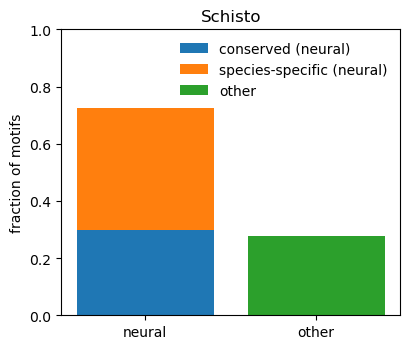

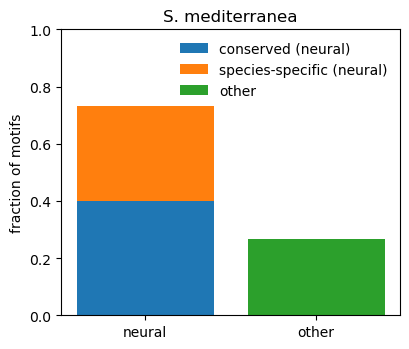

In [39]:
import matplotlib.pyplot as plt

def plot_neural_other_fraction(
    *,
    conserved_neural: int,
    specific_neural: int,
    other: int,
    species_name: str = "",
    ax=None,
):
    """
    Same plot as before but values converted to FRACTIONS
    (normalized by total motifs).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.2, 3.6))

    # ---- convert to fractions ----
    total = conserved_neural + specific_neural + other
    cons_f  = conserved_neural / total if total > 0 else 0
    spec_f  = specific_neural / total if total > 0 else 0
    other_f = other / total if total > 0 else 0

    x = ["neural", "other"]

    # stacked neural
    ax.bar(x[0], cons_f, label="conserved (neural)")
    ax.bar(x[0], spec_f, bottom=cons_f, label="species-specific (neural)")

    # single other bar
    ax.bar(x[1], other_f, label="other")

    ax.set_ylabel("fraction of motifs")
    ax.set_ylim(0, 1)
    ax.set_title(species_name if species_name else "Motif breakdown")
    ax.legend(frameon=False)

    return ax


# -------------------------
# Plot each species
# -------------------------

ax = plot_neural_other_fraction(
    conserved_neural=schisto_conserved_neural,
    specific_neural=schisto_specific_neural,
    other=schisto_other,
    species_name="Schisto",
)
plt.tight_layout()
plt.savefig("./Figures/Figure6/Smed_peaks_schisto_model_motif_fraction.svg",dpi=600)
plt.show()

ax = plot_neural_other_fraction(
    conserved_neural=Smed_conserved_neural,
    specific_neural=Smed_specific_neural,
    other=Smed_other,
    species_name="S. mediterranea",
)
plt.tight_layout()
plt.savefig("./Figures/Figure6/schisto_peaks_Smed_model_motif_fraction.svg",dpi=600)

plt.show()